# Python for AI — Class 18
### Machine Learning: predict a house price

**Machine Learning (ML)** = the computer learns a rule from **examples**, instead of us writing the rule.

Today's problem: **guess the price of a house in Lahore** from its size, bedrooms, age and distance.

**Remember the video?** A line goes through the dots. The small red lines are the **residuals**. We square them and add them up. The model finds the line with the **smallest total**. Today we do all of this in Python.

**Plan for today:**
1. Follow the **ML workflow**, step by step. We write the code one step at a time.
2. At the end, put all the steps together in **one complete program**.
3. **Practice**: quick checks, and a home problem.

**Tip:** Run a cell with `Shift + Enter`.

### New words today

| Word | Meaning |
|------|---------|
| **feature** (`X`) | the information we give the model (size, bedrooms...) |
| **target** (`y`) | what we want the model to guess (price) |
| **model** | the rule the computer learns from data |
| **train / test** | the data the model learns from / the data we keep hidden to check it |
| **regression** | guessing a **number** (price, marks, temperature) |
| **slope** (β1, `coef_`) | how much the price changes when the feature goes up by 1 |
| **intercept** (β0, `intercept_`) | the starting value of the line (also called **bias**) |
| **residual** | real value − predicted value (the error for one house) |
| **loss function** | one number that tells how bad the line is; the model makes it as small as it can |
| **MAE, MSE, RMSE, R²** | different ways to measure the error (Step 7) |

# The ML workflow

Every ML project follows the same steps:

**Look at the data → Prepare X, y → Choose a model → Train → Predict → Residuals → Measure the error**

## Step 1: Look at the data

Before we choose a model, we **look** at the data. We ask 2 questions:
1. Is the target a **number** or a **group**?
2. Do the dots look like a **straight line**?

| Column | Meaning |
|--------|---------|
| `size_marla` | size of the house in marla |
| `bedrooms` | number of bedrooms |
| `age_years` | how old the house is |
| `distance_km` | distance from the city centre (km) |
| `price_lakh` | the price it was sold for (lakh Rs) |

**Using Colab?** The CSV files are in the same folder as this notebook. In Colab, click the **folder icon** on the left → **upload** the CSV files first.

In [2]:
import pandas as pd

houses = pd.read_csv("houses.csv")   # 200 houses sold in Lahore
print(houses.shape)                  # 200 houses, 5 columns
houses.head()

(200, 5)


,size_marla,bedrooms,age_years,distance_km,price_lakh
0,11,5,4,7.7,131.3
1,12,5,17,14.2,113.5
2,16,5,4,14.4,170.9
3,20,8,12,13.0,185.3
4,3,3,21,11.2,31.2


**Question 1:** `price_lakh` is a **number**. So this is a **regression** problem.

**Question 2:** Draw each feature against the price (like Class 16).

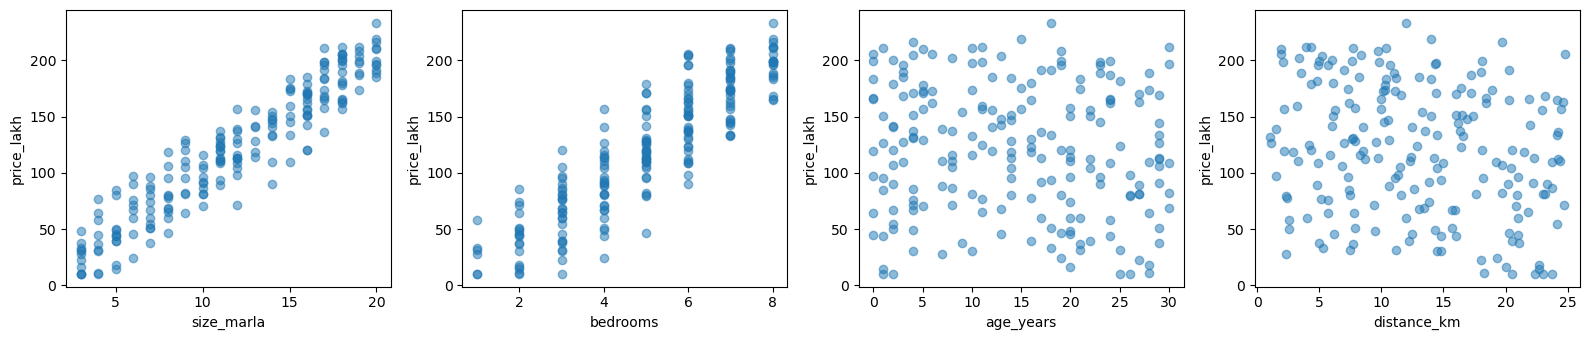

In [3]:
import matplotlib.pyplot as plt

features = ["size_marla", "bedrooms", "age_years", "distance_km"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, features):
    ax.scatter(houses[col], houses["price_lakh"], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("price_lakh")
plt.tight_layout()
plt.show()

**What we see:**
- `size_marla`: the dots go **up** in a clear straight line.
- `bedrooms`: the dots also go **up**.
- `age_years`, `distance_km`: the dots go a little **down**, with a lot of spread.

Correlation (Class 16) gives the same answer in numbers:

In [4]:
houses.corr()["price_lakh"].round(2)

size_marla     0.95
bedrooms       0.89
age_years     -0.11
distance_km   -0.21
price_lakh     1.00
Name: price_lakh, dtype: float64

- Close to **+1** or **−1** = strong straight line.
- Close to **0** = weak.

Size and bedrooms are strong. So a **straight-line model** is a good first try.

## Step 2: Prepare X, y and split

- **X** (features) = the information we **give** the model: size, bedrooms, age, distance.
- **y** (target) = what we want the model to **guess**: the price.
- `houses[features]` = `houses[["size_marla", "bedrooms", ...]]`: a **list** of columns gives a **table**. `houses["price_lakh"]`: **one** name gives **one** column.
- **Split, like exams:** you practise with past papers (**train**), then sit a real exam with new questions (**test**).
- `random_state=42` = shuffle the same way every time, so we all get the same result.

In [5]:
X = houses[features]        # features: what we give the model
y = houses["price_lakh"]    # target: what we want to guess

print("X:", X.shape)    # 200 rows, 4 columns
print("y:", y.shape)    # 200 prices
X.head(3)

X: (200, 4)
y: (200,)


,size_marla,bedrooms,age_years,distance_km
0,11,5,4,7.7
1,12,5,17,14.2
2,16,5,4,14.4


In [6]:
# On your own laptop, install once:  pip install scikit-learn
from sklearn.model_selection import train_test_split

# 80% to learn from, 20% to test the model later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", len(X_train), "houses")
print("Test: ", len(X_test), "houses")

Train: 160 houses
Test:  40 houses


## Step 3: Choose a model

**First, the type of problem:**

| The target is... | Problem type | Example models |
|------------------|--------------|----------------|
| a **number** (price, marks) | Regression | Linear Regression, Decision Tree, KNN |
| a **group** (yes/no, pass/fail) | Classification | next class |

**Then, the shape of the data:**

| The dots look like... | Try first |
|-----------------------|-----------|
| a straight line | Linear Regression |
| a curve, or steps | Decision Tree, KNN |

**What each model does:**
- **Linear Regression**: draws the best **straight line** through the dots.
- **Decision Tree**: asks yes/no questions, like a flowchart: *"Is size more than 10 marla? Is age less than 5?"*
- **KNN** (K-Nearest Neighbours): finds the **5 most similar** houses and takes their average price.

**The rule:** start simple. Try a few models. Keep the one with the **smallest error on the test data**.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
}

for name, m in models.items():
    m.fit(X_train, y_train)                                   # same 3 steps for every model:
    err = mean_absolute_error(y_test, m.predict(X_test))      # create → fit → predict
    print(name, "→ average error:", round(err, 1), "lakh")

Linear Regression → average error: 11.8 lakh
Decision Tree → average error: 18.0 lakh
KNN → average error: 13.7 lakh


**Linear Regression wins** (about 12 lakh, the others 14 and 18).

**Why?** Our dots make a straight line, so a straight-line model fits best. This matches what we saw in Step 1.

**scikit-learn** (`sklearn`) is a free Python library full of ready-made models. Every model works in the same 3 steps: **create → fit → predict**.

## Step 4: Train: how Linear Regression draws the line

From the video: **y = mx + b**, also written **y = β0 + β1 · x**

- **β1 = slope** (`coef_`): how much the price goes up for **1 more marla**.
- **β0 = intercept** (`intercept_`): where the line starts (when x = 0). Also called **bias**.
- `fit` finds the β0 and β1 that make the **squared residuals as small as possible**.

First we use **only 1 feature** (size), so we can draw the line.

In [8]:
line_model = LinearRegression()
line_model.fit(X_train[["size_marla"]], y_train)

b1 = line_model.coef_[0]
b0 = line_model.intercept_
print("slope (β1):", round(b1, 2))
print("intercept (β0):", round(b0, 2))
print("Rule: price =", round(b0, 1), "+", round(b1, 2), "× size")

slope (β1): 10.45
intercept (β0): -3.92
Rule: price = -3.9 + 10.45 × size


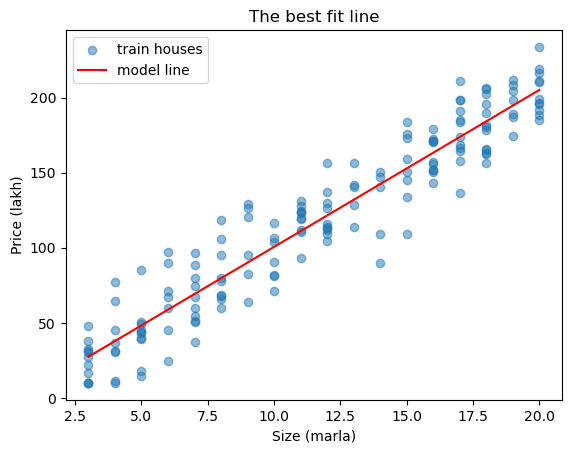

In [9]:
sizes = pd.DataFrame({"size_marla": range(3, 21)})

plt.scatter(X_train["size_marla"], y_train, alpha=0.5, label="train houses")
plt.plot(sizes["size_marla"], line_model.predict(sizes), color="red", label="model line")
plt.xlabel("Size (marla)")
plt.ylabel("Price (lakh)")
plt.title("The best fit line")
plt.legend()
plt.show()

- Each extra marla adds about **10.5 lakh**.
- The red line goes through the **middle** of the dots. This is the **best fit line**.
- The intercept is **−3.9**. A 0-marla house does not exist, so do not read it as a price. It is only where the line starts.

### 🔍 Behind the scenes 1: what are the coefficient and the intercept?

On the picture below:
- **Intercept (β0)** = where the line **crosses** the price axis (size = 0).
- **Coefficient / slope (β1)** = go **1 marla right**, and the line goes **10.45 lakh up**. (In the picture we go 5 marla right, so it goes 5 × 10.45 ≈ 52 lakh up.)

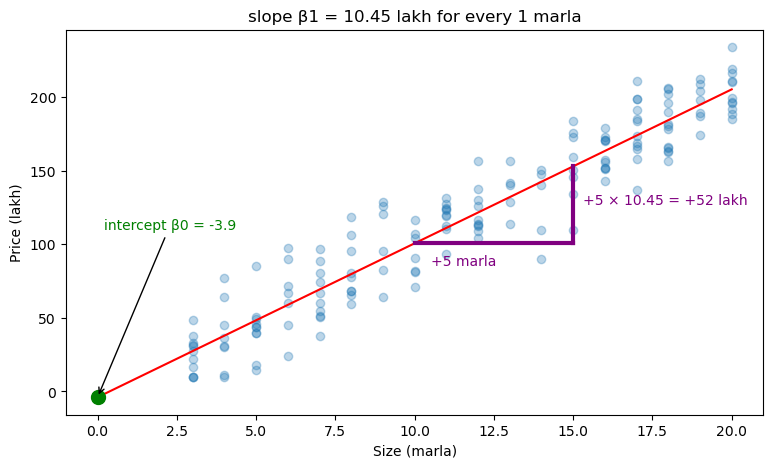

In [10]:
xs = pd.DataFrame({"size_marla": range(0, 21)})
plt.figure(figsize=(9, 5))
plt.scatter(X_train["size_marla"], y_train, alpha=0.3)
plt.plot(xs["size_marla"], line_model.predict(xs), color="red")

# intercept: the line at size = 0
plt.scatter([0], [b0], color="green", s=100, zorder=3)
plt.annotate("intercept β0 = " + str(round(b0, 1)), (0, b0), xytext=(0.2, 110),
             arrowprops={"arrowstyle": "->"}, color="green")

# slope: 5 marla right → 5 × β1 lakh up
x1 = 10
y1 = b0 + b1 * x1
plt.plot([x1, x1 + 5], [y1, y1], color="purple", linewidth=3)                 # 5 marla right
plt.plot([x1 + 5, x1 + 5], [y1, y1 + 5 * b1], color="purple", linewidth=3)    # 5 × β1 up
plt.text(x1 + 0.5, y1 - 15, "+5 marla", color="purple")
plt.text(x1 + 5.3, y1 + 2.5 * b1, "+5 × " + str(round(b1, 2)) + " = +" + str(round(5 * b1)) + " lakh", color="purple")
plt.title("slope β1 = " + str(round(b1, 2)) + " lakh for every 1 marla")

plt.xlabel("Size (marla)")
plt.ylabel("Price (lakh)")
plt.show()

### 🔍 Behind the scenes 2: what does `model.fit` do?

`fit` looks for the line with the **smallest error**. In simple words:
1. **Try** a line (pick a β0 and a β1).
2. **Measure** how bad it is: the **MSE** (average of the squared residuals).
3. **Keep** the line with the **smallest MSE**.
4. **Save** the best numbers in `coef_` (β1) and `intercept_` (β0).

Let's do it ourselves with pandas. We try 3 lines on the train houses:

Line A → MSE: 1122.3
Line B → MSE: 693.1
Line C (fit) → MSE: 330.8


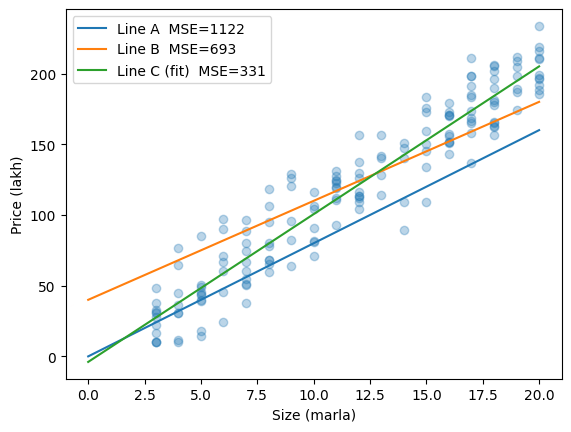

In [57]:
size = X_train["size_marla"]
price = y_train

lines = {
    "Line A": (0, 8),             # (β0, β1) we guessed
    "Line B": (40, 7),            # (β0, β1) we guessed
    "Line C (fit)": (b0, b1),     # the numbers model.fit found
}

plt.scatter(size, price, alpha=0.3)
for name, (try_b0, try_b1) in lines.items():
    guess = try_b0 + try_b1 * size                    # the line's price for every house
    mse = ((price - guess) ** 2).mean()       # average of squared residuals
    print(name, "→ MSE:", round(mse, 1))
    plt.plot(xs["size_marla"], try_b0 + try_b1 * xs["size_marla"], label=name + "  MSE=" + str(round(mse)))

plt.xlabel("Size (marla)")
plt.ylabel("Price (lakh)")
plt.legend()
plt.show()

**Line C has the smallest MSE.** No other line can beat it. That is the line `fit` gave us.

But `fit` does **not** try lines one by one. It uses a **formula** that jumps straight to the best line. It is called **Least Squares**.

### The Least Squares formula

$$\beta_1 = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sum (x - \bar{x})^2} \qquad\qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

| Symbol | Meaning | In our code |
|--------|---------|-------------|
| $x$ | size of each house | `size` |
| $y$ | price of each house | `price` |
| $\bar{x}$ ("x bar") | average size | `size_mean` |
| $\bar{y}$ ("y bar") | average price | `price_mean` |
| $\sum$ ("sigma") | add up for **all** 160 houses | `.sum()` |

**In words:**
- **slope β1** = (how much size and price move **together**) ÷ (how much size moves **alone**)
- **intercept β0** = average price − β1 × average size. So the line always goes through the **middle point** (average size, average price).

Let's use the formula with pandas, and compare with `fit`:

In [71]:
size_mean = size.mean()
price_mean = price.mean()

my_b1 = ((size - size_mean) * (price - price_mean)).sum() / ((size - size_mean) ** 2).sum()
my_b0 = price_mean - my_b1 * size_mean

print("By hand    → slope:", round(my_b1, 2), " intercept:", round(my_b0, 2))
print("model.fit  → slope:", round(line_model.coef_[0], 2), " intercept:", round(line_model.intercept_, 2))

By hand    → slope: 10.45  intercept: -3.92
model.fit  → slope: 10.45  intercept: -3.92


**With our numbers:** $\bar{x}$ = 11.72 marla, $\bar{y}$ = 118.55 lakh, so

$$\beta_0 = 118.55 - 10.45 \times 11.72 = -3.9$$

**The same numbers!** So `model.fit` = this formula. It does the math for us.

With 4 features the formula is bigger (matrix math), but the job is the same: find the βs with the **smallest MSE**.

**With 4 features**, the model learns **one slope per feature**:

**price = β0 + β1 × size + β2 × bedrooms + β3 × age + β4 × distance**

We cannot draw it on paper (in the video, it is a **hyperplane**). But the idea is the same.

In [59]:
model = LinearRegression()     # 1. create
model.fit(X_train, y_train)    # 2. fit = learn from the 160 train houses

print(pd.Series(model.coef_, index=X.columns).round(2))
print("intercept:", round(model.intercept_, 1))

size_marla     7.68
bedrooms       8.26
age_years     -0.71
distance_km   -1.54
dtype: float64
intercept: 18.3


**What the model learned:**
- each extra **marla** adds about **7.7 lakh**
- each extra **bedroom** adds about **8.3 lakh**
- each year **older** takes away about **0.7 lakh**
- each km **further** from the centre takes away about **1.5 lakh**

**How does the model know to guess the price?** We told it: `y = houses["price_lakh"]`, then `model.fit(X_train, y_train)`.

## Step 5: Predict

- Give the model a **table with the same column names** as `X`.
- `model.predict(...)` gives a list of prices. `[0]` takes the first one.
- Inside, it just does the sum: β0 + β1 × 10 + β2 × 4 + β3 × 5 + β4 × 8.

In [60]:
new_house = pd.DataFrame({"size_marla": [10], "bedrooms": [4], "age_years": [5], "distance_km": [8]})
print("Predicted price:", model.predict(new_house)[0].round(1), "lakh")

Predicted price: 112.2 lakh


**🔍 Behind the scenes 3: what does `predict` do?** Multiply each feature by its coefficient, add them up, then add the intercept. Let's do it with pandas:

In [78]:
coef = pd.Series(model.coef_, index=X.columns)
house = new_house.iloc[0]          # the new house as one row

print(pd.DataFrame({"value": house, "coef": coef.round(2), "value × coef": (house * coef).round(1)}))
print("sum of value × coef:", round((house * coef).sum(), 1))
print("+ intercept:        ", round(model.intercept_, 1))
print("= price by hand:    ", round((house * coef).sum() + model.intercept_, 1), "lakh")

             value  coef  value × coef
size_marla      10  7.68          76.8
bedrooms         4  8.26          33.0
age_years        5 -0.71          -3.6
distance_km      8 -1.54         -12.3
sum of value × coef: 93.9
+ intercept:         18.3
= price by hand:     112.2 lakh


### ✏️ QUICK CHECK 1: Predict another house

Predict the price of a house with: **5 marla, 3 bedrooms, 20 years old, 15 km** from the centre.

Is it cheaper than the 10 marla house? Why?

Write your code in the cell below.

In [62]:
# Write your code here

## Step 6: Residuals

- **Residual** = real price − predicted price. These are the small red lines in the video.
- **Positive** residual: the model guessed **too low**.
- **Negative** residual: the model guessed **too high**.

In [63]:
compare = pd.DataFrame({"real": y_test, "predicted": model.predict(X_test).round(1)})
compare["residual"] = (compare["real"] - compare["predicted"]).round(1)
compare.head(8)

,real,predicted,residual
95,185.4,184.1,1.3
15,86.2,77.6,8.6
30,80.5,59.6,20.9
158,131.5,147.9,-16.4
128,92.0,94.7,-2.7
115,200.2,203.6,-3.4
69,144.7,137.9,6.8
170,46.3,76.1,-29.8


**See the residuals.** We use the 1-feature line again, because we can draw it. Each orange line is one residual.

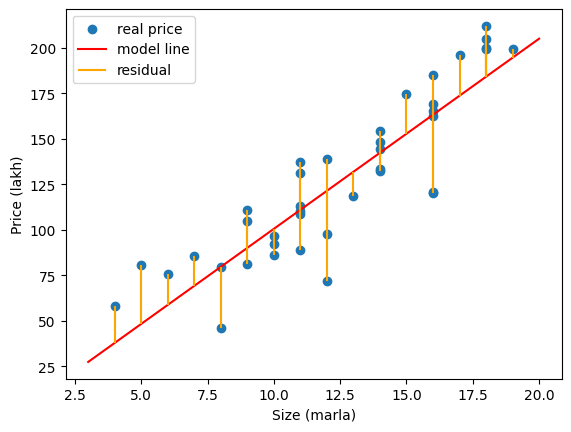

In [64]:
pred_line = line_model.predict(X_test[["size_marla"]])

plt.scatter(X_test["size_marla"], y_test, label="real price")
plt.plot(sizes["size_marla"], line_model.predict(sizes), color="red", label="model line")
plt.vlines(X_test["size_marla"], y_test, pred_line, color="orange", label="residual")
plt.xlabel("Size (marla)")
plt.ylabel("Price (lakh)")
plt.legend()
plt.show()

## Step 7: Measure the error

We have **40 residuals**. We want **one number** for the whole model. There are a few ways:

| Name | How we get it | Unit |
|------|---------------|------|
| **MAE** (Mean Absolute Error) | average of residuals, without the minus sign | lakh |
| **MSE** (Mean Squared Error) | average of residuals **squared** | lakh² |
| **RMSE** (Root MSE) | square root of MSE | lakh |
| **R²** (R-squared) | how much of the price the model explains: 1 = perfect, 0 = useless | no unit |

**Why square?** Squaring makes **big mistakes count much more** (the squares in the video). Small example with 3 residuals:

In [80]:
import numpy as np

residuals = np.array([2, -4, 10])
print("MAE:", np.abs(residuals).mean().round(1))   # (2 + 4 + 10) / 3
print("MSE:", (residuals ** 2).mean().round(1))    # (4 + 16 + 100) / 3  → the 10 became 100!

MAE: 5.3
MSE: 40.0


Now for our house model:

In [81]:
from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)

print("MAE :", round(mean_absolute_error(y_test, pred), 1), "lakh")
print("MSE :", round(mse, 1), "lakh²")
print("RMSE:", round(mse ** 0.5, 1), "lakh")
print("R²  :", round(r2_score(y_test, pred), 2))

MAE : 11.8 lakh
MSE : 204.7 lakh²
RMSE: 14.3 lakh
R²  : 0.9


**What the output means, and what we DO with each number:**

| Number | What it means | What we do with it |
|--------|---------------|--------------------|
| **MAE ≈ 11.8** | each guess is about **12 lakh** too high or too low | **tell the customer**: "give or take 12 lakh" |
| **MSE ≈ 205** | the misses squared, then averaged (lakh², hard to read) | **nothing**. `fit` uses it inside to find the best line |
| **RMSE ≈ 14.3** | like MAE, but big mistakes count more | if it is much bigger than MAE, some guesses are **very** wrong |
| **R² ≈ 0.90** | a **score out of 1**: the model explains **90%** of the price | **check if the model is good**: near 1 = good, near 0 = bad |

**In short:** look at **MAE** (how many lakh we miss) and **R²** (how good the model is). MSE is for the computer.

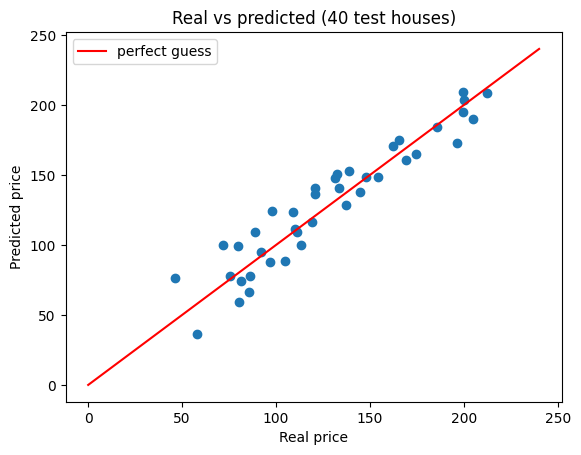

In [67]:
plt.scatter(y_test, pred)
plt.plot([0, 240], [0, 240], color="red", label="perfect guess")
plt.xlabel("Real price")
plt.ylabel("Predicted price")
plt.title("Real vs predicted (40 test houses)")
plt.legend()
plt.show()

- A dot **on** the red line = a perfect guess.
- The distance from the line = the residual.

**Is 12 lakh a big error?**
- MAE = 12 lakh. So each guess is about 12 lakh **too high or too low**.
- An average house costs about **120 lakh**. 12 ÷ 120 = **10%**. Good for only 4 columns!

**Back to our new house from Step 5** (10 marla): the model said **112 lakh**.
- 112 − 12 = **100** lakh
- 112 + 12 = **124** lakh

**So, to the customer, we say:** *"The price is about 112 lakh. The real price is probably between 100 and 124 lakh."*

### ✏️ QUICK CHECK 2: Is one feature enough?

Train a new model with **only** `size_marla` as the feature. Find its MAE on the test houses.

Is it better or worse than the model with 4 features?

(Hint: use `X_train[["size_marla"]]` to train, and `X_test[["size_marla"]]` to predict.)

Write your code in the cell below.

In [68]:
# Write your code here

### How can we make the error smaller?

1. **Add better features**, like `area_name` or `has_parking`. This helps the most. (1 feature → 4 features made the error go from 16 to 12 lakh.)
2. **Collect more data.**
3. **Clean the data**: fix wrong rows, remove strange values.
4. **Try another model**, but only when the dots make a curve.

Some error always stays. Price also depends on things that are not in our file, like the exact area or the condition of the house.

# All steps together: the complete program

This is everything we did today, in **one cell**. Read the comments: each one is a step from today.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Step 1: Load the data
houses = pd.read_csv("houses.csv")

# Step 2: X = features, y = target. Then split 80% train, 20% test
X = houses[["size_marla", "bedrooms", "age_years", "distance_km"]]
y = houses["price_lakh"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3 + 4: Choose Linear Regression, create it, and train it
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Predict the price of a NEW house
new_house = pd.DataFrame({"size_marla": [10], "bedrooms": [4], "age_years": [5], "distance_km": [8]})
print("Predicted price:", round(model.predict(new_house)[0], 1), "lakh")

# Step 6 + 7: Residuals and error on the 40 test houses

from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)

print("MAE :", round(mean_absolute_error(y_test, pred), 1), "lakh")
print("MSE :", round(mse, 1), "lakh²")
print("RMSE:", round(mse ** 0.5, 1), "lakh")
print("R²  :", round(r2_score(y_test, pred), 2))

Predicted price: 112.2 lakh
MAE : 11.8 lakh
MSE : 204.7 lakh²
RMSE: 14.3 lakh
R²  : 0.9


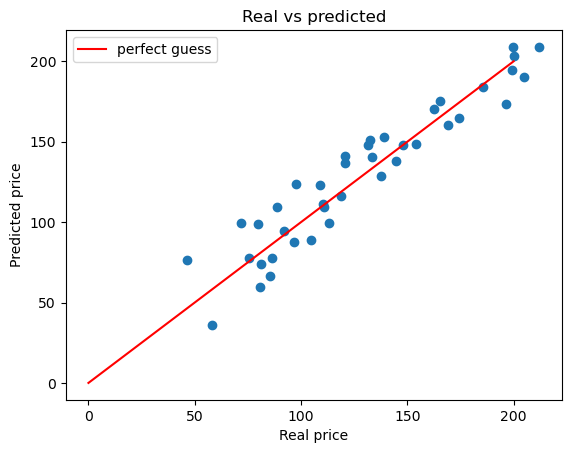

In [7]:
import matplotlib.pyplot as plt
plt.scatter(y_test, pred)
plt.plot([0, 200], [0, 200], color="red", label="perfect guess")
plt.xlabel("Real price")
plt.ylabel("Predicted price")
plt.title("Real vs predicted")
plt.legend()
plt.show()

# 🏠 Home Problem: Used car prices

A used-car showroom in Karachi asks: *"Can you suggest a fair price for a used car?"*

`cars.csv` has 200 sold cars:

| Column | Meaning |
|--------|---------|
| `car_age` | age of the car in years |
| `km_thousands` | how far it was driven, in thousand km (60 = 60,000 km) |
| `engine_cc` | engine size (660 to 1800) |
| `price_lakh` | the price it was sold for (lakh Rs) |

**Follow the same workflow:**

1. **Look:** load `cars.csv`. Draw each feature against `price_lakh` and print the correlation. Which features look like a straight line?
2. **Prepare:** make `X` (the 3 features) and `y` (`price_lakh`). Split with `test_size=0.2, random_state=42`.
3. **Choose:** try `LinearRegression`, `DecisionTreeRegressor` and `KNeighborsRegressor`. Which has the smallest MAE?
4. **Train:** train a `LinearRegression`. Print `coef_` and `intercept_`, and explain each number in words.
5. **Predict** the price of a **5-year-old, 1300cc car driven 60,000 km**.
6. **Residuals:** show a table of real, predicted and residual for the first 8 test cars.
7. **Error:** print MAE, MSE, RMSE and R².

**Bring to the next class:** your code, and 2 sentences for the showroom (the price, and the average error).

In [3]:
# Write your code here
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Step 1: Load the data
cars = pd.read_csv("cars.csv")

# Step 2: X = features, y = target. Then split 80% train, 20% test
X = cars[["car_age", "km_thousands", "engine_cc"]]
y = cars["price_lakh"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3 + 4: Choose Linear Regression, create it, and train it
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Predict the price of a NEW house
new_car = pd.DataFrame({"car_age": [5], "km_thousands": [60], "engine_cc" : [1300]})
print("Predicted price:", round(model.predict(new_car)[0], 1), "lakh")

# Step 6 + 7: Residuals and error on the 40 test houses
error = mean_absolute_error(y_test, model.predict(X_test))
print("Average error (MAE):", round(error, 1), "lakh")

Predicted price: 31.5 lakh
Average error (MAE): 2.0 lakh


# Key Takeaways

- **ML** = the computer learns the rule from examples.
- **Workflow:** look at the data → prepare X, y → choose a model → train → predict → residuals → error.
- Target is a **number** → regression. Dots in a **straight line** → try Linear Regression first.
- Try a few models. Keep the one with the **smallest test error**.
- Linear Regression learns a **slope** for each feature and an **intercept**.
- **Residual** = real − predicted.
- `fit` makes the **MSE** (the loss) as small as possible. We explain the result with **MAE**.

**Next class:** Classification: guessing a **group** (like *approved* / *not approved*) instead of a number.